In [ ]:
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)


In [ ]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "Mine" else Path.cwd().resolve()

NORMAL_DATA_PATH = ROOT / "Dataset" / "SWaT_Dataset_Normal_v1.parquet"
ATTACK_DATA_PATH = ROOT / "Dataset" / "SWaT_Dataset_Attack_v1.parquet"

SEQ_LEN = 64
STRIDE = 1
EXPECTED_STEP_SECONDS = 1

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 256
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 6

TCN_CHANNELS = [64, 128, 128]
KERNEL_SIZE = 3
LSTM_HIDDEN_SIZE = 128
LSTM_NUM_LAYERS = 1
DROPOUT = 0.2

device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)
print("device:", device)


device: mps


In [3]:
def load_normal_attack_data():
    df_normal = pd.read_parquet(NORMAL_DATA_PATH).copy()
    df_attack = pd.read_parquet(ATTACK_DATA_PATH).copy()

    if "Timestamp" in df_normal.columns:
        df_normal["Timestamp"] = pd.to_datetime(df_normal["Timestamp"], errors="coerce")
        df_normal = df_normal.sort_values("Timestamp").reset_index(drop=True)
    if "Timestamp" in df_attack.columns:
        df_attack["Timestamp"] = pd.to_datetime(df_attack["Timestamp"], errors="coerce")
        df_attack = df_attack.sort_values("Timestamp").reset_index(drop=True)

    if "Label" not in df_normal.columns:
        df_normal["Label"] = 0
    else:
        df_normal["Label"] = df_normal["Label"].astype(int)

    if "Label" not in df_attack.columns:
        if "Detailed_Label" not in df_attack.columns:
            raise ValueError("Attack data has no Label or Detailed_Label column.")
        df_attack["Label"] = (df_attack["Detailed_Label"].astype(str) != "0").astype(int)
    else:
        df_attack["Label"] = df_attack["Label"].astype(int)

    return df_normal, df_attack


df_normal, df_attack = load_normal_attack_data()
print("normal shape:", df_normal.shape)
print("attack shape:", df_attack.shape)
print("attack label counts:\n", df_attack["Label"].value_counts())


normal shape: (495000, 55)
attack shape: (449919, 55)
attack label counts:
 Label
0    395298
1     54621
Name: count, dtype: int64


In [4]:
def summarize_time_gaps(df: pd.DataFrame, time_col: str = "Timestamp", expected_step_seconds: int = 1):
    if time_col not in df.columns:
        return pd.DataFrame(columns=["prev_timestamp", time_col, "gap_seconds"])

    ts = pd.to_datetime(df[time_col])
    diff = ts.diff().dt.total_seconds()
    gaps = df.loc[diff > expected_step_seconds, [time_col]].copy()
    gaps.insert(0, "prev_timestamp", ts.shift(1)[diff > expected_step_seconds].values)
    gaps["gap_seconds"] = diff[diff > expected_step_seconds].values
    return gaps.reset_index(drop=True)


normal_gaps = summarize_time_gaps(df_normal, expected_step_seconds=EXPECTED_STEP_SECONDS)
attack_gaps = summarize_time_gaps(df_attack, expected_step_seconds=EXPECTED_STEP_SECONDS)

print("normal gaps:", len(normal_gaps))
print("attack gaps:", len(attack_gaps))
if len(attack_gaps):
    display(attack_gaps.sort_values("gap_seconds", ascending=False).head(10))


normal gaps: 0
attack gaps: 1


,prev_timestamp,Timestamp,gap_seconds
0,2015-12-31 21:00:36,2015-12-31 21:01:58,82.0


In [5]:
drop_cols = ["index", "Timestamp", "Label", "Detailed_Label"]
feature_cols = [
    col for col in df_attack.columns
    if col not in drop_cols and pd.api.types.is_numeric_dtype(df_attack[col])
]

if not feature_cols:
    raise ValueError("No numeric feature columns found.")

print("num_features:", len(feature_cols))
print(feature_cols)


num_features: 51
['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603']


In [6]:
def chronological_split(df: pd.DataFrame, train_ratio: float, val_ratio: float):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train_df = df.iloc[:train_end].reset_index(drop=True)
    val_df = df.iloc[train_end:val_end].reset_index(drop=True)
    test_df = df.iloc[val_end:].reset_index(drop=True)
    return train_df, val_df, test_df


normal_train_df, normal_val_df, normal_test_df = chronological_split(df_normal, TRAIN_RATIO, VAL_RATIO)
attack_train_df, attack_val_df, attack_test_df = chronological_split(df_attack, TRAIN_RATIO, VAL_RATIO)

print("normal split:", normal_train_df.shape, normal_val_df.shape, normal_test_df.shape)
print("attack split:", attack_train_df.shape, attack_val_df.shape, attack_test_df.shape)
print("attack train labels:\n", attack_train_df["Label"].value_counts())
print("attack val labels:\n", attack_val_df["Label"].value_counts())
print("attack test labels:\n", attack_test_df["Label"].value_counts())


normal split: (346500, 55) (74250, 55) (74250, 55)
attack split: (314943, 55) (67488, 55) (67488, 55)
attack train labels:
 Label
0    265627
1     49316
Name: count, dtype: int64
attack val labels:
 Label
0    65861
1     1627
Name: count, dtype: int64
attack test labels:
 Label
0    63810
1     3678
Name: count, dtype: int64


In [7]:
scaler = MinMaxScaler()

train_fit_df = pd.concat([
    normal_train_df[feature_cols],
    attack_train_df[feature_cols],
], axis=0, ignore_index=True)
scaler.fit(train_fit_df)


def transform_split(df: pd.DataFrame):
    X = scaler.transform(df[feature_cols])
    y = df["Label"].to_numpy(dtype=np.int64)
    timestamps = df["Timestamp"].to_numpy() if "Timestamp" in df.columns else None
    return X, y, timestamps


normal_train_x, normal_train_y, normal_train_ts = transform_split(normal_train_df)
normal_val_x, normal_val_y, normal_val_ts = transform_split(normal_val_df)
normal_test_x, normal_test_y, normal_test_ts = transform_split(normal_test_df)

attack_train_x, attack_train_y, attack_train_ts = transform_split(attack_train_df)
attack_val_x, attack_val_y, attack_val_ts = transform_split(attack_val_df)
attack_test_x, attack_test_y, attack_test_ts = transform_split(attack_test_df)


In [8]:
def make_sequences(
    X: np.ndarray,
    y: np.ndarray,
    seq_len: int,
    stride: int = 1,
    timestamps=None,
    expected_step_seconds: int = 1,
):
    X_seq, y_seq = [], []
    skipped_windows = 0

    ts_seconds = None
    if timestamps is not None:
        ts_seconds = pd.to_datetime(pd.Series(timestamps)).astype("int64") // 10**9
        ts_seconds = ts_seconds.to_numpy()

    for start in range(0, len(X) - seq_len + 1, stride):
        end = start + seq_len

        if ts_seconds is not None:
            deltas = np.diff(ts_seconds[start:end])
            if not np.all(deltas == expected_step_seconds):
                skipped_windows += 1
                continue

        X_window = X[start:end]
        y_window = y[start:end]
        X_seq.append(X_window)
        y_seq.append(int(y_window.max()))

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.int64), skipped_windows


def build_source_sequences(name: str, X, y, timestamps):
    X_seq, y_seq, skipped = make_sequences(
        X, y, SEQ_LEN, STRIDE, timestamps, EXPECTED_STEP_SECONDS
    )
    print(f"{name}: X={X_seq.shape}, y={y_seq.shape}, skipped={skipped}, positives={int(y_seq.sum())}")
    return X_seq, y_seq


normal_train_seq, normal_train_label = build_source_sequences("normal_train", normal_train_x, normal_train_y, normal_train_ts)
normal_val_seq, normal_val_label = build_source_sequences("normal_val", normal_val_x, normal_val_y, normal_val_ts)
normal_test_seq, normal_test_label = build_source_sequences("normal_test", normal_test_x, normal_test_y, normal_test_ts)

attack_train_seq, attack_train_label = build_source_sequences("attack_train", attack_train_x, attack_train_y, attack_train_ts)
attack_val_seq, attack_val_label = build_source_sequences("attack_val", attack_val_x, attack_val_y, attack_val_ts)
attack_test_seq, attack_test_label = build_source_sequences("attack_test", attack_test_x, attack_test_y, attack_test_ts)


normal_train: X=(346437, 64, 51), y=(346437,), skipped=0, positives=0
normal_val: X=(74187, 64, 51), y=(74187,), skipped=0, positives=0
normal_test: X=(74187, 64, 51), y=(74187,), skipped=0, positives=0
attack_train: X=(314817, 64, 51), y=(314817,), skipped=63, positives=50869
attack_val: X=(67425, 64, 51), y=(67425,), skipped=0, positives=1879
attack_test: X=(67425, 64, 51), y=(67425,), skipped=0, positives=4056


In [9]:
X_train = np.concatenate([normal_train_seq, attack_train_seq], axis=0)
y_train = np.concatenate([normal_train_label, attack_train_label], axis=0)

X_val = np.concatenate([normal_val_seq, attack_val_seq], axis=0)
y_val = np.concatenate([normal_val_label, attack_val_label], axis=0)

X_test = np.concatenate([normal_test_seq, attack_test_seq], axis=0)
y_test = np.concatenate([normal_test_label, attack_test_label], axis=0)

train_perm = np.random.default_rng(42).permutation(len(X_train))
val_perm = np.random.default_rng(43).permutation(len(X_val))
test_perm = np.random.default_rng(44).permutation(len(X_test))

X_train, y_train = X_train[train_perm], y_train[train_perm]
X_val, y_val = X_val[val_perm], y_val[val_perm]
X_test, y_test = X_test[test_perm], y_test[test_perm]

print("train:", X_train.shape, y_train.shape, dict(zip(*np.unique(y_train, return_counts=True))))
print("val  :", X_val.shape, y_val.shape, dict(zip(*np.unique(y_val, return_counts=True))))
print("test :", X_test.shape, y_test.shape, dict(zip(*np.unique(y_test, return_counts=True))))


train: (661254, 64, 51) (661254,) {np.int64(0): np.int64(610385), np.int64(1): np.int64(50869)}
val  : (141612, 64, 51) (141612,) {np.int64(0): np.int64(139733), np.int64(1): np.int64(1879)}
test : (141612, 64, 51) (141612,) {np.int64(0): np.int64(137556), np.int64(1): np.int64(4056)}


In [10]:
train_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float())
val_dataset = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float())
test_dataset = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

seq_len = X_train.shape[1]
input_dim = X_train.shape[2]
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32, device=device)

print("seq_len:", seq_len)
print("input_dim:", input_dim)
print("pos_weight:", pos_weight.item())


seq_len: 64
input_dim: 51
pos_weight: 11.999155044555664


## 模型

模型結構：

- 多層 Temporal CNN 抽取局部時間特徵
- BiLSTM 學習長短期雙向依賴
- Global average pooling + 線性層輸出二元分類 logit


In [11]:
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        padding = dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.activation = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = self.downsample(x)
        return self.activation(out + res)


class TemporalCNNBiLSTM(nn.Module):
    def __init__(self, input_dim, tcn_channels, kernel_size, lstm_hidden_size, lstm_num_layers, dropout):
        super().__init__()

        blocks = []
        in_channels = input_dim
        for i, out_channels in enumerate(tcn_channels):
            blocks.append(
                TemporalBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=2 ** i,
                    dropout=dropout,
                )
            )
            in_channels = out_channels
        self.tcn = nn.Sequential(*blocks)

        self.bilstm = nn.LSTM(
            input_size=tcn_channels[-1],
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_num_layers > 1 else 0.0,
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, lstm_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden_size, 1),
        )

    def forward(self, x):
        # x: [batch, seq_len, features]
        x = x.transpose(1, 2)
        x = self.tcn(x)
        x = x.transpose(1, 2)
        x, _ = self.bilstm(x)
        x = x.mean(dim=1)
        logits = self.classifier(x).squeeze(-1)
        return logits


In [12]:
model = TemporalCNNBiLSTM(
    input_dim=input_dim,
    tcn_channels=TCN_CHANNELS,
    kernel_size=KERNEL_SIZE,
    lstm_hidden_size=LSTM_HIDDEN_SIZE,
    lstm_num_layers=LSTM_NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(model)


TemporalCNNBiLSTM(
  (tcn): Sequential(
    (0): TemporalBlock(
      (net): Sequential(
        (0): Conv1d(51, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
        (7): Dropout(p=0.2, inplace=False)
      )
      (downsample): Conv1d(51, 64, kernel_size=(1,), stride=(1,))
      (activation): ReLU()
    )
    (1): TemporalBlock(
      (net): Sequential(
        (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(128, 128, kernel_size=(3,), str

In [13]:
def collect_probs_and_labels(model, loader, device):
    model.eval()
    probs_list = []
    labels_list = []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            logits = model(batch_x)
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_list.append(probs)
            labels_list.append(batch_y.numpy())

    return np.concatenate(probs_list), np.concatenate(labels_list)


def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    return total_loss / len(loader.dataset)


def find_best_threshold(y_true, probs):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    if len(thresholds) == 0:
        return 0.5, 0.0

    f1_scores = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    best_idx = int(np.nanargmax(f1_scores))
    return float(thresholds[best_idx]), float(f1_scores[best_idx])


In [14]:
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1 = -1.0
best_threshold = 0.5
best_state_dict = None
wait = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    val_probs, val_true = collect_probs_and_labels(model, val_loader, device)
    val_threshold, val_best_f1 = find_best_threshold(val_true, val_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_best_f1)

    print(
        f"Epoch [{epoch:03d}/{EPOCHS}] "
        f"train_loss={train_loss:.6f} "
        f"val_loss={val_loss:.6f} "
        f"val_best_f1={val_best_f1:.4f} "
        f"threshold={val_threshold:.4f}"
    )

    if val_best_f1 > best_val_f1:
        best_val_f1 = val_best_f1
        best_threshold = val_threshold
        best_state_dict = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

print("best_val_f1:", best_val_f1)
print("best_threshold:", best_threshold)


Epoch [001/30] train_loss=0.163067 val_loss=1.314519 val_best_f1=0.1078 threshold=0.5960
Epoch [002/30] train_loss=0.086414 val_loss=0.586817 val_best_f1=0.4833 threshold=0.6223
Epoch [003/30] train_loss=0.068927 val_loss=1.050103 val_best_f1=0.5391 threshold=0.9344
Epoch [004/30] train_loss=0.057906 val_loss=1.199496 val_best_f1=0.5075 threshold=0.9498
Epoch [005/30] train_loss=0.050438 val_loss=1.050126 val_best_f1=0.0996 threshold=0.9211
Epoch [006/30] train_loss=0.045137 val_loss=1.263735 val_best_f1=0.1214 threshold=0.9969
Epoch [007/30] train_loss=0.042836 val_loss=1.637492 val_best_f1=0.3171 threshold=0.8491
Epoch [008/30] train_loss=0.039905 val_loss=1.568914 val_best_f1=0.4552 threshold=0.9891
Epoch [009/30] train_loss=0.038356 val_loss=2.776893 val_best_f1=0.1840 threshold=0.1401
Early stopping at epoch 9
best_val_f1: 0.5391169635941131
best_threshold: 0.9344419836997986


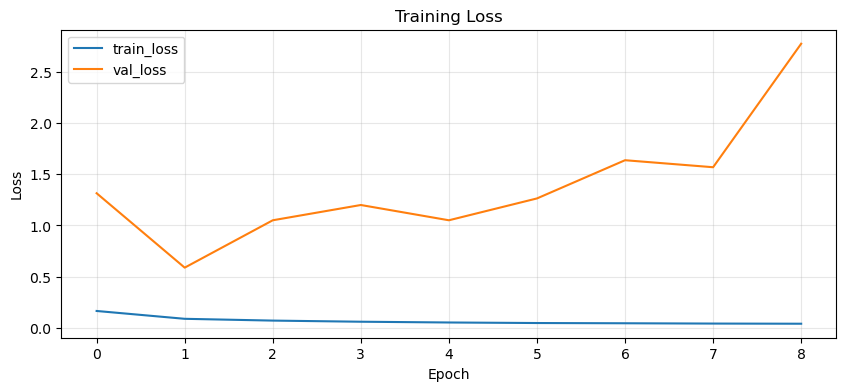

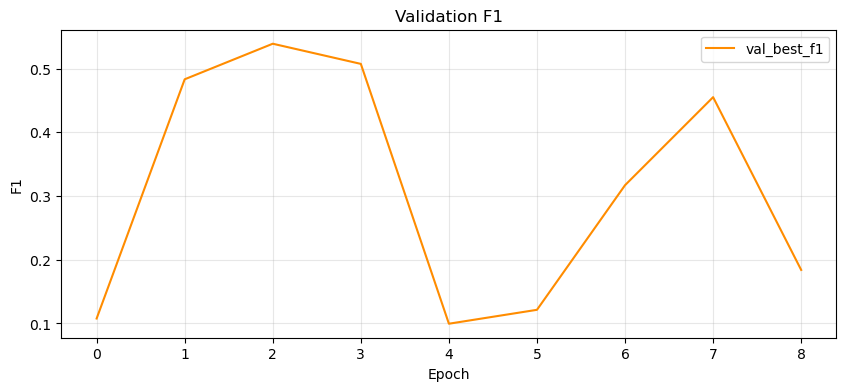

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["val_f1"], label="val_best_f1", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Validation F1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [16]:
test_probs, test_true = collect_probs_and_labels(model, test_loader, device)
test_pred = (test_probs >= best_threshold).astype(int)

acc = accuracy_score(test_true, test_pred)
precision = precision_score(test_true, test_pred, zero_division=0)
recall = recall_score(test_true, test_pred, zero_division=0)
f1 = f1_score(test_true, test_pred, zero_division=0)
cm = confusion_matrix(test_true, test_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Threshold: {best_threshold:.4f}")
print("\nClassification Report")
print(classification_report(test_true, test_pred, digits=4, zero_division=0))
print("Confusion Matrix:\n", cm)


Accuracy : 0.9752
Precision: 0.8747
Recall   : 0.1583
F1-score : 0.2681
Threshold: 0.9344

Classification Report
              precision    recall  f1-score   support

         0.0     0.9758    0.9993    0.9874    137556
         1.0     0.8747    0.1583    0.2681      4056

    accuracy                         0.9752    141612
   macro avg     0.9252    0.5788    0.6277    141612
weighted avg     0.9729    0.9752    0.9668    141612

Confusion Matrix:
 [[137464     92]
 [  3414    642]]


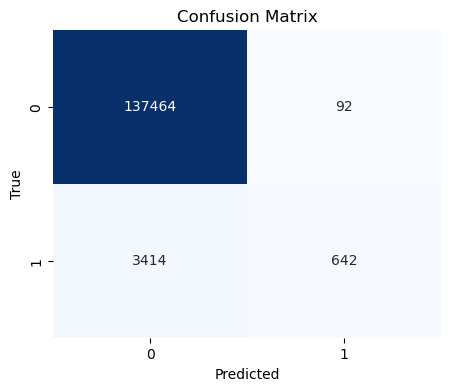

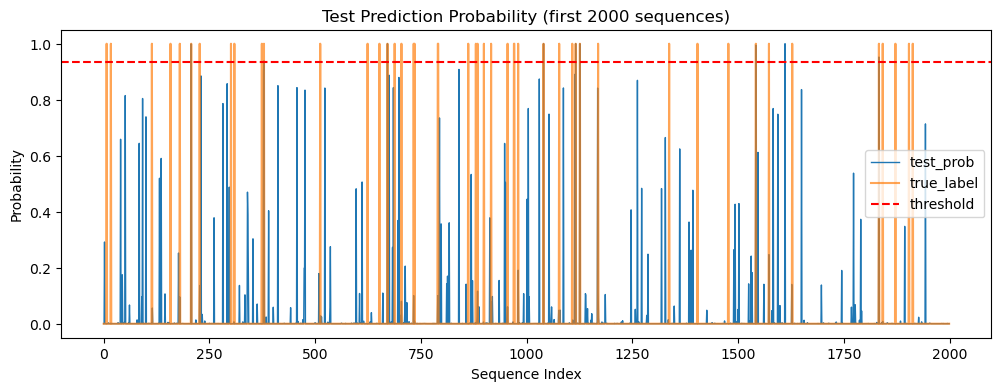

In [17]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(test_probs[:2000], label="test_prob", linewidth=1)
plt.plot(test_true[:2000], label="true_label", alpha=0.7)
plt.axhline(best_threshold, color="red", linestyle="--", label="threshold")
plt.xlabel("Sequence Index")
plt.ylabel("Probability")
plt.title("Test Prediction Probability (first 2000 sequences)")
plt.legend()
plt.show()
